<a href="https://colab.research.google.com/github/princealexanderm/-ICT_AI_ML/blob/main/ICT_AI_ML__Assignment_05_Artificial_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ICT_AI_ML_ Assignment 05_Artifical Neural Network_Prince

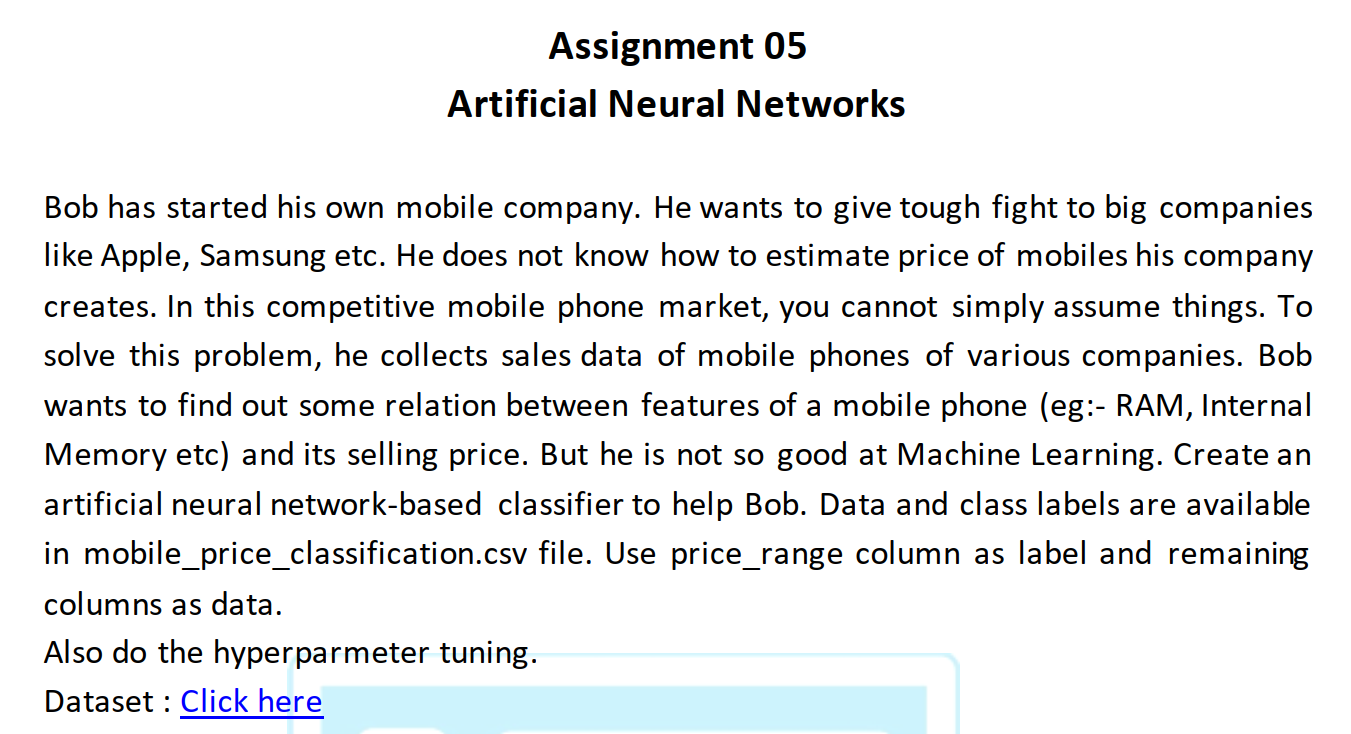

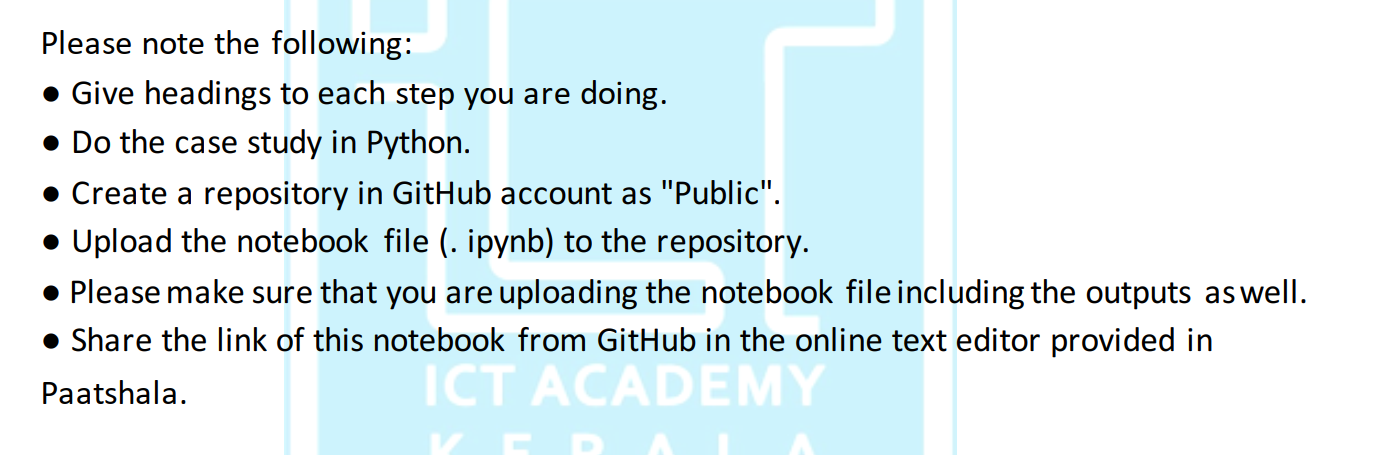

Data:https://drive.google.com/file/d/1YNuSslEtvOXx3_whqdY54ZqIuBGvRUvd/view

#1. Import necessary modules

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import argmax
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# 2. Load the data

In [194]:
df=pd.read_csv('/content/mobile_price_classification.csv')
df.sample(10)

,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
170,1270,1,0.6,1,2,1,32,0.5,101,7,...,299,845,3770,5,3,13,1,1,0,3
1782,1436,1,2.4,1,3,1,23,0.3,106,5,...,189,1411,2488,8,4,8,1,0,0,2
969,1345,1,3.0,0,7,1,38,0.1,162,3,...,512,1465,1322,9,2,15,1,0,0,1
156,637,0,2.3,0,3,1,60,0.8,97,4,...,1125,1989,374,18,4,8,1,0,1,0
430,1887,1,3.0,1,6,1,17,0.2,126,8,...,1172,1798,3348,18,16,16,1,1,0,3
970,904,0,1.6,1,5,1,14,0.2,102,8,...,56,760,1846,7,0,3,1,0,1,1
806,1511,0,2.5,1,3,0,21,0.2,114,3,...,1455,1982,3746,10,0,5,1,0,0,3
1941,1522,0,2.2,0,4,0,21,0.7,162,6,...,533,1696,3767,15,9,16,0,0,1,3
1636,1561,0,0.5,1,10,1,4,0.5,134,2,...,885,1811,1783,13,12,10,1,1,0,2
1880,1720,0,1.6,0,18,1,2,0.8,188,5,...,334,896,2522,10,5,2,1,0,1,2


In [195]:
df['price_range'].value_counts()

,count
price_range,
1,500
2,500
3,500
0,500


4 different price range

So this is a classification problem.

# 3. Shape of the data

In [196]:
df.shape

(2000, 21)

21 columns

#4. Basic info

In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   battery_power   2000 non-null   int64  
 1   bluetooth       2000 non-null   int64  
 2   clock_speed     2000 non-null   float64
 3   dual_sim        2000 non-null   int64  
 4   front_cam       2000 non-null   int64  
 5   4G              2000 non-null   int64  
 6   int_memory      2000 non-null   int64  
 7   m_dep           2000 non-null   float64
 8   mobile_wt       2000 non-null   int64  
 9   n_cores         2000 non-null   int64  
 10  primary_camera  2000 non-null   int64  
 11  px_height       2000 non-null   int64  
 12  px_width        2000 non-null   int64  
 13  ram             2000 non-null   int64  
 14  sc_h            2000 non-null   int64  
 15  sc_w            2000 non-null   int64  
 16  talk_time       2000 non-null   int64  
 17  three_g         2000 non-null   i

all are numerical columns

#5. Summary statistics of the data

In [198]:
df.describe()

,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


# 6. Spliting in to features and labels

In [199]:
x=df.drop('price_range',axis=1)
y=df['price_range']

In [200]:
x.head(4)

,battery_power,bluetooth,clock_speed,dual_sim,front_cam,4G,int_memory,m_dep,mobile_wt,n_cores,primary_camera,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0


In [201]:
y.head(4)

,price_range
0,1
1,2
2,2
3,2


# 7. Splitting the data for training and testing

In [202]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [203]:
print('x_train shape:',x_train.shape)
print('x_test shape:',x_test.shape)
print('y_train shape:',y_train.shape)
print('y_test shape:',y_test.shape)

x_train shape: (1600, 20)
x_test shape: (400, 20)
y_train shape: (1600,)
y_test shape: (400,)


In [204]:
n_features=x_train.shape[1]
n_features

20

#8. Scaling the data

In [205]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

20 columns in featuers

In [206]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#9. MLP for Multiclass Deeplaerning

In [207]:
model=Sequential()
model.add(Dense(64,activation='relu',input_shape=(n_features,)))
model.add(Dense(32,activation='relu'))
model.add(Dense(4,activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 10.Compile the model

In [208]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

# 11.Train the model

In [209]:
history=model.fit(x_train,y_train,epochs=100,batch_size=16,verbose=0) # verbose=1 shows all epoch values

#12.Evaluate the model

In [210]:
loss,acc=model.evaluate(x_test,y_test,verbose=0)
print('Test Accuracy: %.3f' % acc)

Test Accuracy: 0.928


In [219]:
x_test[0:2]

array([[ 0.91965677, -0.98142253,  1.20299532, -1.03046381, -0.30198725,
         0.95596841, -0.39968162,  0.33974965,  1.68047209, -1.11062276,
        -0.81126756, -0.97289129,  0.83197042, -1.32373775, -1.00379215,
         0.06786732,  0.00783234,  0.55713671,  0.9900495 , -0.99750312],
       [-0.13347738, -0.98142253, -1.23622976, -1.03046381,  0.62011122,
         0.95596841, -1.3342879 , -0.00893505, -0.07455319,  1.51031591,
         1.0181122 , -0.82916721, -0.60986264,  0.4136243 ,  1.61272768,
         2.60388619,  1.46078725,  0.55713671, -1.0100505 , -0.99750312]])

In [220]:
x_test_arr0=np.array([ 0.91965677, -0.98142253,  1.20299532, -1.03046381, -0.30198725,
         0.95596841, -0.39968162,  0.33974965,  1.68047209, -1.11062276,
        -0.81126756, -0.97289129,  0.83197042, -1.32373775, -1.00379215,
         0.06786732,  0.00783234,  0.55713671,  0.9900495 , -0.99750312])
x_test_arr0

array([ 0.91965677, -0.98142253,  1.20299532, -1.03046381, -0.30198725,
        0.95596841, -0.39968162,  0.33974965,  1.68047209, -1.11062276,
       -0.81126756, -0.97289129,  0.83197042, -1.32373775, -1.00379215,
        0.06786732,  0.00783234,  0.55713671,  0.9900495 , -0.99750312])

In [221]:
x_test_arr1=np.array([-0.13347738, -0.98142253, -1.23622976, -1.03046381,  0.62011122,
         0.95596841, -1.3342879 , -0.00893505, -0.07455319,  1.51031591,
         1.0181122 , -0.82916721, -0.60986264,  0.4136243 ,  1.61272768,
         2.60388619,  1.46078725,  0.55713671, -1.0100505 , -0.99750312])
x_test_arr1

array([-0.13347738, -0.98142253, -1.23622976, -1.03046381,  0.62011122,
        0.95596841, -1.3342879 , -0.00893505, -0.07455319,  1.51031591,
        1.0181122 , -0.82916721, -0.60986264,  0.4136243 ,  1.61272768,
        2.60388619,  1.46078725,  0.55713671, -1.0100505 , -0.99750312])

In [222]:
y_test[0:5]

,price_range
1860,0
353,2
1333,1
905,3
1289,1


# 13.predict the model

In [223]:
import numpy as np
row = [ 0.91965677, -0.98142253,  1.20299532, -1.03046381, -0.30198725,
         0.95596841, -0.39968162,  0.33974965,  1.68047209, -1.11062276,
        -0.81126756, -0.97289129,  0.83197042, -1.32373775, -1.00379215,
         0.06786732,  0.00783234,  0.55713671,  0.9900495 , -0.99750312] # Example row for prediction
yhat = model.predict(np.array([row]))
print('Predicted probabilities:', yhat[0])
print('Predicted class index:', argmax(yhat))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted probabilities: [9.9165970e-01 8.3403215e-03 2.7705185e-09 6.8351692e-18]
Predicted class index: 0


In [224]:
import numpy as np
row = [-0.13347738, -0.98142253, -1.23622976, -1.03046381,  0.62011122,
         0.95596841, -1.3342879 , -0.00893505, -0.07455319,  1.51031591,
         1.0181122 , -0.82916721, -0.60986264,  0.4136243 ,  1.61272768,
         2.60388619,  1.46078725,  0.55713671, -1.0100505 , -0.99750312] # Example row for prediction
yhat = model.predict(np.array([row]))
print('Predicted probabilities:', yhat[0])
print('Predicted class index:', argmax(yhat))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted probabilities: [4.1641868e-10 3.5302010e-03 9.9642533e-01 4.4478780e-05]
Predicted class index: 2
